# import and load all

In [1]:
%load_ext autoreload
%autoreload all

In [47]:
import torch

import numpy as np
import polars as pl
from tqdm import tqdm
import torch.nn.functional as F

from functions.utils import load_config, get_tensor_from_numpy
config = load_config() 
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
cpt_label_ref_embs = np.load(config["EMBEDDING_CONCEPT"]["cpt_snomed_ref_emb"])
df_map_ref = pl.read_parquet(config["EMBEDDING_CONCEPT"]["cpt_snomed_ref_info"])

cpt_label_ehrshot_embs = np.load(config["EMBEDDING_CONCEPT"]["cpt_ehrshot_emb"])
df_concept_ehrshot = pl.read_parquet(config["EMBEDDING_CONCEPT"]["cpt_ehrshot_info"])


In [4]:

cpt_label_ref_embs = get_tensor_from_numpy(cpt_label_ref_embs, device)
cpt_label_ehrshot_embs = get_tensor_from_numpy(cpt_label_ehrshot_embs, device)

emb_c = F.normalize(cpt_label_ref_embs, dim=1)
emb_q = F.normalize(cpt_label_ehrshot_embs, dim=1)

In [5]:
# map concepts by cosine similarity
rows = []
for i in tqdm(range(emb_q.shape[0])):
    sim = emb_q[i,:] @ emb_c.T
    sim_score, sim_index = sim.max(dim=0)
    rows.append(
        {
            "ehrshot_concept_id": df_concept_ehrshot[i]["code_value"][0],
            "ehrshot_label": df_concept_ehrshot[i]["label"][0],
            "ref_concept_id": df_map_ref[sim_index.item()]["id"][0],
            "ref_label": df_map_ref[sim_index.item()]["label"][0],
            "similarity_score": sim_score.item(),
        }
    )
df_mapping = pl.DataFrame(rows)

100%|██████████| 30759/30759 [06:20<00:00, 80.74it/s]


In [50]:

# df_mapping.join(df_concept_ehrshot.select("code_value", "bool_map_direct", "count"), left_on= "ref_concept_id", right_on="code_value", how="left")
(df_concept_ehrshot.select("code_value", "bool_map_direct", "code_type", "count")
    .join(df_mapping, left_on="code_value", right_on="ehrshot_concept_id")
    .unique()
    .rename({
        "code_value": "ehrshot_concept_id",
        "bool_map_direct": "exact_to_snomed",
        "code_type": "ehrshot_concept_original_ontology",
        "count": "frequency",
        "ref_concept_id": "best_matched_snomed_concept_id",
        "ref_label": "best_matched_snomed_label",
    })
    .select([
        "exact_to_snomed",
        "ehrshot_concept_id",
        "ehrshot_concept_original_ontology",
        "ehrshot_label",
        "frequency",
        "best_matched_snomed_concept_id",
        "best_matched_snomed_label",
        "similarity_score"
        ]
    )
    .write_parquet(config["vocab_data"]["path"] + config["vocab_data"]["mapping"]))

# analysis

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
df_concept_mappped = pl.read_parquet(config["vocab_data"]["path"] + config["vocab_data"]["mapping"])
df_concept_mappped_approx = df_concept_mappped.filter(pl.col("exact_to_snomed") == False)

<AxesSubplot: ylabel='Count'>

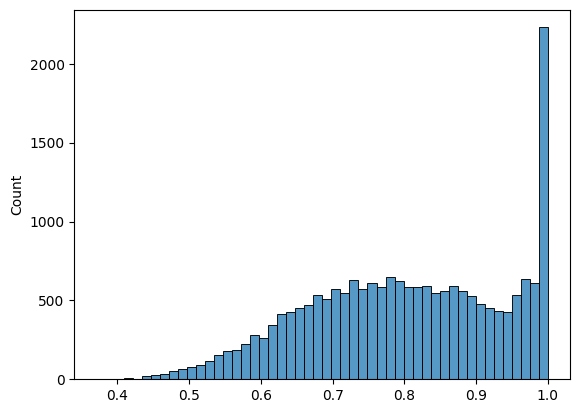

In [59]:
sns.histplot(df_concept_mappped_approx.select("similarity_score").to_numpy().flatten(), bins=50)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'RxNorm'),
  Text(1, 0, 'CPT4'),
  Text(2, 0, 'LOINC'),
  Text(3, 0, 'ICD10PCS'),
  Text(4, 0, 'SNOMED'),
  Text(5, 0, 'ICD9Proc'),
  Text(6, 0, 'RxNorm Extension'),
  Text(7, 0, 'ICDO3'),
  Text(8, 0, 'Domain'),
  Text(9, 0, 'HCPCS'),
  Text(10, 0, 'CVX'),
  Text(11, 0, 'Cancer Modifier'),
  Text(12, 0, 'Visit'),
  Text(13, 0, 'Race'),
  Text(14, 0, 'OMOP Extension'),
  Text(15, 0, 'CMS Place of Service'),
  Text(16, 0, 'Gender'),
  Text(17, 0, 'Ethnicity'),
  Text(18, 0, 'Condition Type'),
  Text(19, 0, 'Medicare Specialty')])

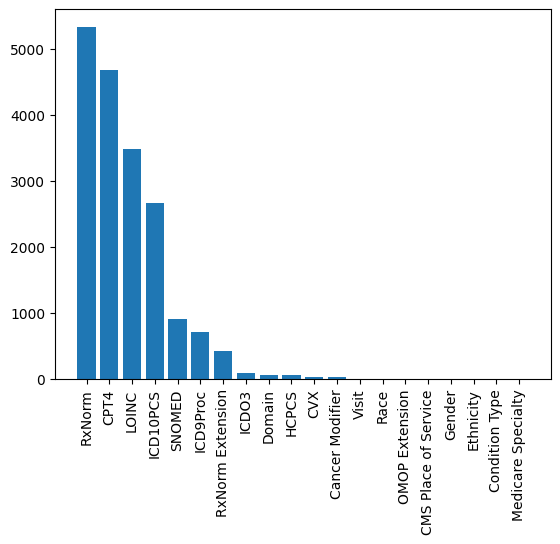

In [ ]:
df = df_concept_mappped_approx.filter(pl.col("similarity_score")>=0.6)["ehrshot_concept_original_ontology"].value_counts().sort(by="count",descending=True)
plt.bar(df["ehrshot_concept_original_ontology"], df["count"])
plt.xticks(rotation=90)

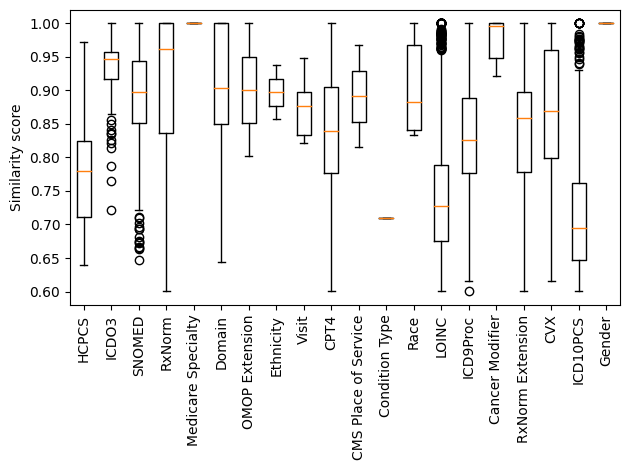

In [78]:
df2 = (
    df_concept_mappped_approx
    .filter(pl.col("similarity_score")>=0.6)
    .group_by("ehrshot_concept_original_ontology")
    .agg(pl.col("similarity_score"))
)

data = df2["similarity_score"].to_list()
labels = df2["ehrshot_concept_original_ontology"].to_list()

plt.figure()
plt.boxplot(data, labels=labels)
plt.xticks(rotation=90)
plt.ylabel("Similarity score")
plt.tight_layout()
plt.show()


In [94]:
df3 = (
    df_concept_mappped
    .filter(pl.col("similarity_score")<0.60)
   
)


(df3["frequency"].sum()/df_concept_mappped["frequency"].sum())*100

0.21002817333105475

In [ ]:
df3 = (
    df_concept_mappped_approx
    .filter(pl.col("similarity_score")<0.7)
   
)

exact_to_snomed,ehrshot_concept_id,ehrshot_concept_original_ontology,ehrshot_label,frequency,best_matched_snomed_concept_id,best_matched_snomed_label,similarity_score
bool,str,str,str,u32,str,str,f64
false,"""819601000000102""","""SNOMED""","""Human herpes virus 6 IgG antib…",6,"""710456005""","""Herpes virus 6 IgG""",0.921958
false,"""93544""","""CPT4""","""Injection procedure during car…",4,"""419470007""","""Cardiac angiogram and aspirati…",0.758159
false,"""22327""","""CPT4""","""Open treatment and/or reductio…",6,"""179655000""","""Revision to open reduction of …",0.678668
true,"""441988000""","""SNOMED""","""Imaging of abdomen abnormal (f…",346,"""441988000""","""Imaging of abdomen abnormal (f…",1.0
false,"""0WPF0YZ""","""ICD10PCS""","""Removal of Other Device from A…",1,"""708991001""","""Non-operative removal of devic…",0.613201
…,…,…,…,…,…,…,…
false,"""0KU307Z""","""ICD10PCS""","""Supplement Left Neck Muscle wi…",2,"""3181000087102""","""MRI of left wrist with contras…",0.480291
true,"""28656008""","""SNOMED""","""Congenital insufficiency of ao…",412,"""28656008""","""Congenital insufficiency of ao…",1.0
false,"""6194-5""","""LOINC""","""Orange IgE Ab [Units/volume] i…",19,"""387989001""","""Orange specific IgE""",0.734006
